# Problem Set 01 - Pediatric Chest X-ray Dataset Exploration

This notebook inspects the pediatric chest X-ray dataset used in the assignment. The goal is to understand the dataset structure before any modeling work. We will not train or build a CNN in this notebook.

The dataset is organized into `train`, `val`, and `test` folders, with two classes:
- NORMAL
- PNEUMONIA

## 1. Project and dataset structure

We begin by confirming the directory layout and the expected class folders. This ensures that the file paths used in later analysis are correct and that we are not modifying or deleting any files.

In [19]:
# Import the libraries needed for directory inspection and image analysis
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Define the dataset root and expected splits/classes
DATA_DIR = Path("data/chest_xray")
SPLITS = ["train", "val", "test"]
CLASSES = ["NORMAL", "PNEUMONIA"]

# Print the directory structure for a quick sanity check
print("Dataset root:", DATA_DIR.resolve())
for split in SPLITS:
    split_dir = DATA_DIR / split
    print(f"\nSplit: {split_dir}")
    for cls in CLASSES:
        class_dir = split_dir / cls
        num_files = len(list(class_dir.glob("*")))
        print(f"  {cls}: {num_files} images")

# Note: we are only inspecting the data and generating summary statistics.
# We do not modify or delete any files in the dataset.

Dataset root: D:\Problem Set 01\data\chest_xray

Split: data\chest_xray\train
  NORMAL: 1341 images
  PNEUMONIA: 3875 images

Split: data\chest_xray\val
  NORMAL: 8 images
  PNEUMONIA: 8 images

Split: data\chest_xray\test
  NORMAL: 234 images
  PNEUMONIA: 390 images


## 2. Count images in each split and class

This step calculates how many examples are available in each training, validation, and test folder for each class. These counts help confirm that the dataset is balanced enough for later analysis and modeling.

In [20]:
# Build a summary table of image counts by split and class
rows = []
for split in SPLITS:
    for cls in CLASSES:
        class_dir = DATA_DIR / split / cls
        files = sorted(class_dir.glob("*"))
        rows.append({
            "split": split,
            "class_name": cls,
            "num_images": len(files),
            "folder_path": str(class_dir),
        })

summary_df = pd.DataFrame(rows)
print(summary_df)

# Create a pivot table for easy inspection of class counts by split
pivot_df = summary_df.pivot_table(index="split", columns="class_name", values="num_images", aggfunc="sum")
print("\nPivot table:\n")
print(pivot_df)

   split class_name  num_images                      folder_path
0  train     NORMAL        1341     data\chest_xray\train\NORMAL
1  train  PNEUMONIA        3875  data\chest_xray\train\PNEUMONIA
2    val     NORMAL           8       data\chest_xray\val\NORMAL
3    val  PNEUMONIA           8    data\chest_xray\val\PNEUMONIA
4   test     NORMAL         234      data\chest_xray\test\NORMAL
5   test  PNEUMONIA         390   data\chest_xray\test\PNEUMONIA

Pivot table:

class_name  NORMAL  PNEUMONIA
split                        
test           234        390
train         1341       3875
val              8          8


## 3. Image dimensions and file-level metadata

We now inspect the actual image sizes to determine whether all X-rays share the same dimensions or whether there is variation across the dataset. This is useful for preprocessing and model input configuration.

In [21]:
# Extract image dimensions for every file in the dataset
image_records = []
for split in SPLITS:
    for cls in CLASSES:
        class_dir = DATA_DIR / split / cls
        for image_path in sorted(class_dir.glob("*")):
            if image_path.is_file():
                with Image.open(image_path) as img:
                    image_records.append({
                        "split": split,
                        "class_name": cls,
                        "filename": image_path.name,
                        "width": img.width,
                        "height": img.height,
                        "mode": img.mode,
                    })

image_df = pd.DataFrame(image_records)
print(image_df.head())
print("\nUnique image sizes:\n")
print(image_df[["width", "height"]].drop_duplicates().sort_values(["width", "height"]).reset_index(drop=True))

   split class_name           filename  width  height mode
0  train     NORMAL  IM-0115-0001.jpeg   2090    1858    L
1  train     NORMAL  IM-0117-0001.jpeg   1422    1152    L
2  train     NORMAL  IM-0119-0001.jpeg   1810    1434    L
3  train     NORMAL  IM-0122-0001.jpeg   1618    1279    L
4  train     NORMAL  IM-0125-0001.jpeg   1600    1125    L

Unique image sizes:

      width  height
0       384     127
1       399     164
2       400     138
3       407     178
4       415     354
...     ...     ...
4798   2752    1882
4799   2772    2098
4800   2844    2067
4801   2890    2534
4802   2916    2583

[4803 rows x 2 columns]


## 4. Class distribution and summary statistics

The next step summarizes class imbalance across the dataset. This helps us understand whether the classes are evenly represented or if one class dominates the dataset.

  class_name  total_images
0     NORMAL          1583
1  PNEUMONIA          4273


C:\Users\User\AppData\Local\Temp\ipykernel_4012\3909598964.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=class_distribution, x="class_name", y="total_images", palette="Set2")


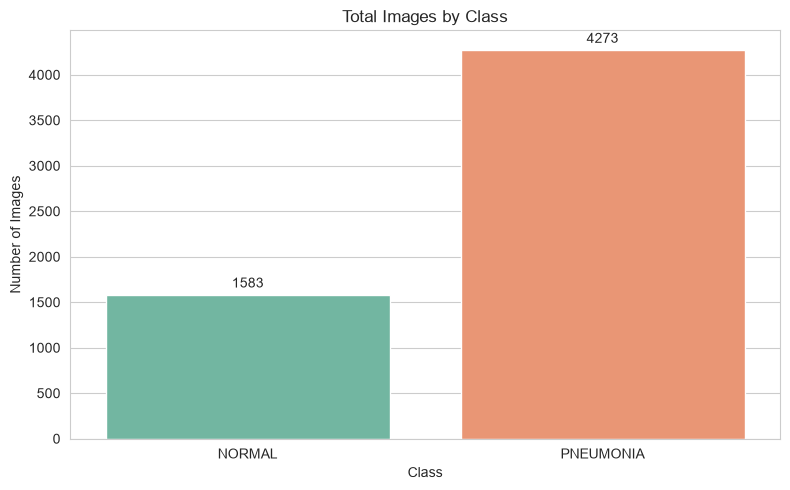

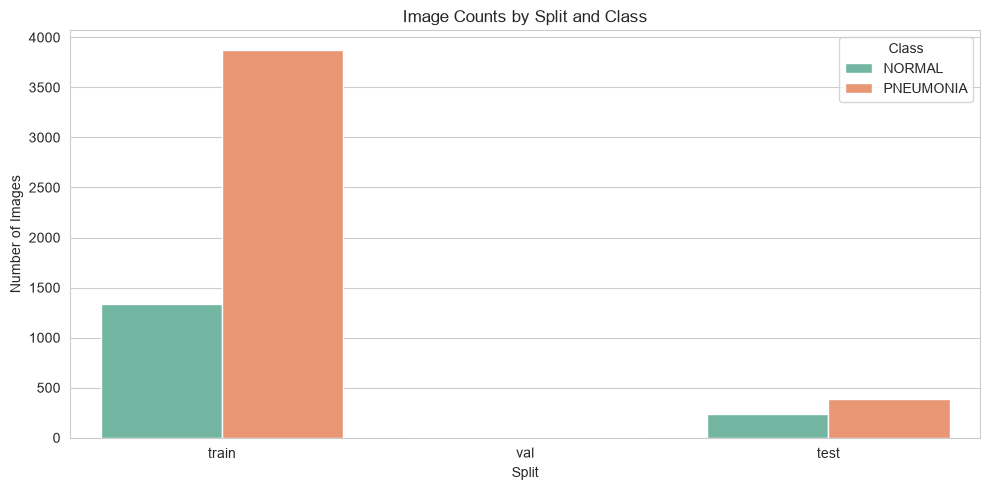

In [22]:
# Aggregate total counts per class across all splits
class_distribution = summary_df.groupby("class_name", as_index=False)["num_images"].sum()
class_distribution = class_distribution.rename(columns={"num_images": "total_images"})
print(class_distribution)

# Create a bar plot for the overall class distribution
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=class_distribution, x="class_name", y="total_images", palette="Set2")
ax.set_title("Total Images by Class")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
plt.tight_layout()
plt.show()

# Also show class counts by split to inspect how the distribution changes across train/val/test
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=summary_df, x="split", y="num_images", hue="class_name", palette="Set2")
ax.set_title("Image Counts by Split and Class")
ax.set_xlabel("Split")
ax.set_ylabel("Number of Images")
ax.legend(title="Class")
plt.tight_layout()
plt.show()

## 5. Sample image visualization

Finally, we display a few representative images from each class and split to visually inspect the dataset. This helps us confirm the images look like chest X-rays and that labels are arranged in the expected folders.

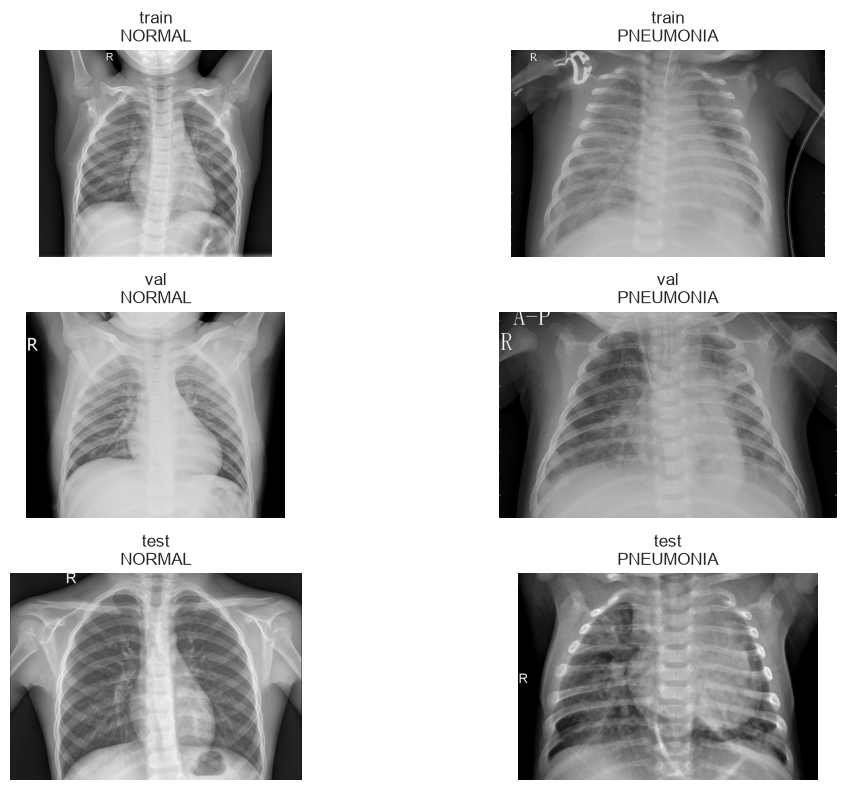

train/NORMAL: IM-0115-0001.jpeg
train/PNEUMONIA: person1000_bacteria_2931.jpeg
val/NORMAL: NORMAL2-IM-1427-0001.jpeg
val/PNEUMONIA: person1946_bacteria_4874.jpeg
test/NORMAL: IM-0001-0001.jpeg
test/PNEUMONIA: person100_bacteria_475.jpeg


In [23]:
# Select one representative image per split and class for quick inspection
sample_paths = []
for split in SPLITS:
    for cls in CLASSES:
        class_dir = DATA_DIR / split / cls
        files = sorted(class_dir.glob("*"))
        if files:
            sample_paths.append(files[0])

fig, axes = plt.subplots(len(SPLITS), len(CLASSES), figsize=(12, 8))

for i, split in enumerate(SPLITS):
    for j, cls in enumerate(CLASSES):
        image_path = (DATA_DIR / split / cls).glob("*")
        image_path = sorted(image_path)[0]
        image = Image.open(image_path).convert("L")
        axes[i, j].imshow(image, cmap="gray")
        axes[i, j].set_title(f"{split}\n{cls}")
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

# Print the actual first sample path for each split/class to confirm label organization
for split in SPLITS:
    for cls in CLASSES:
        first_image = sorted((DATA_DIR / split / cls).glob("*"))[0]
        print(f"{split}/{cls}: {first_image.name}")

## 6. Image preprocessing for CNN input

Before training a CNN, we prepare the chest X-ray images so that every example has the same spatial size and a consistent value range. Resizing to 150x150 pixels makes the input dimensions consistent across all images and reduces computational cost. Normalizing pixel values to the range 0 to 1 keeps the numeric scale stable, which helps training converge more reliably. Data augmentation is applied only to the training set to expose the model to small geometric variations such as slight rotations, zooms, and horizontal flips, which can make the CNN more robust without changing the original dataset files.

Validation and test images are kept in their original clinical orientation and scale for a fair evaluation of model performance.

In [24]:
# Import TensorFlow for building separate preprocessing pipelines for train/val/test
import tensorflow as tf

# Use the dataset folders that already exist in the project structure.
# These are separate splits and should not be modified in place.
train_dir = DATA_DIR / "train"
val_dir = DATA_DIR / "val"
test_dir = DATA_DIR / "test"

# Create the raw dataset loaders for each split.
# We keep the same split structure and only preprocess within the pipeline.
train_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=(150, 150),
    batch_size=32,
    shuffle=True,
    seed=42,
)

val_raw = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=(150, 150),
    batch_size=32,
    shuffle=False,
)

test_raw = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=(150, 150),
    batch_size=32,
    shuffle=False,
)

# Define the augmentation and normalization layers.
# Augmentation is used only on training images to make the model more robust.
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
])

normalization = tf.keras.layers.Rescaling(scale=1.0 / 255)

# Apply preprocessing to each dataset.
# Training data gets augmentation + normalization.
# Validation and test data get normalization only.
train_ds = train_raw.map(lambda x, y: (augmentation(x, training=True), y))
train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds = val_raw.map(lambda x, y: (normalization(x), y))
test_ds = test_raw.map(lambda x, y: (normalization(x), y))

# Prefetch helps keep the pipeline efficient during training and evaluation.
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# Print a few dataset details to confirm the preprocessing pipeline is correct.
print("Class names:", train_raw.class_names)
print("Train batch shape:", next(iter(train_ds))[0].shape)
print("Validation batch shape:", next(iter(val_ds))[0].shape)
print("Test batch shape:", next(iter(test_ds))[0].shape)
print("Pixel range after normalization:", tf.reduce_min(next(iter(train_ds))[0]).numpy(), "to", tf.reduce_max(next(iter(train_ds))[0]).numpy())

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Class names: ['NORMAL', 'PNEUMONIA']
Train batch shape: (32, 150, 150, 1)
Validation batch shape: (16, 150, 150, 1)
Test batch shape: (32, 150, 150, 1)
Pixel range after normalization: 0.0 to 0.99639606


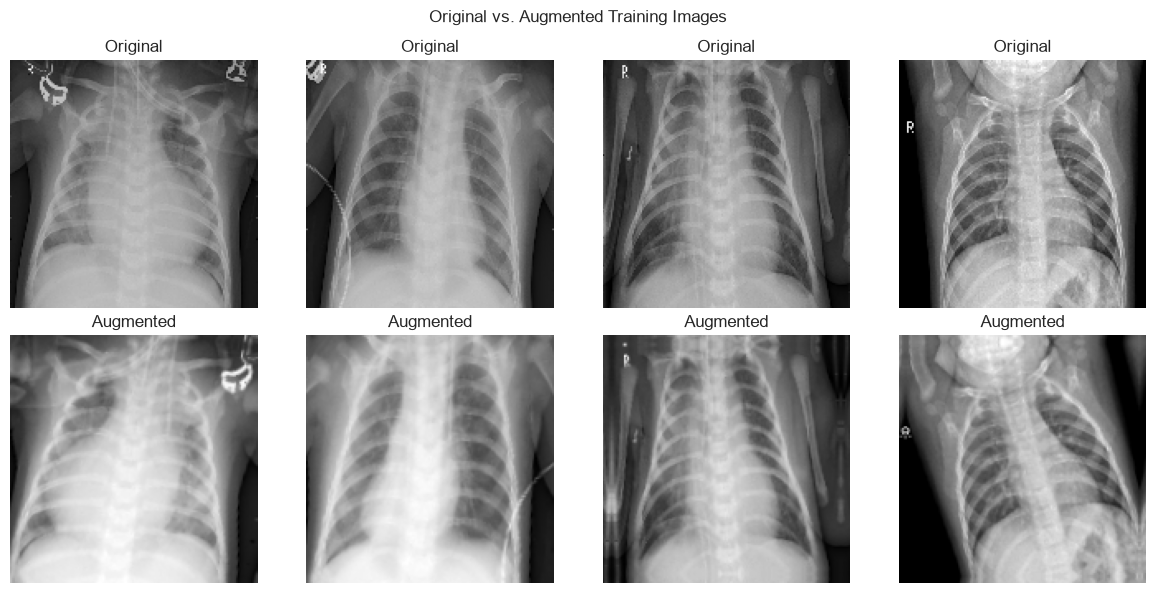

In [25]:
# Show a few augmented training examples to visually verify the preprocessing.
# We use raw training images before normalization so we can compare the original and augmented versions.
raw_batch = next(iter(train_raw))
original_images = raw_batch[0][:4]
augmented_images = augmentation(original_images, training=True)

# Convert image values to a display-friendly range for plotting.
# Original grayscale images are usually 0-255, while normalized images are 0-1.
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Original vs. Augmented Training Images")

for i in range(4):
    axes[0, i].imshow(original_images[i].numpy().squeeze(), cmap="gray")
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    axes[1, i].imshow(augmented_images[i].numpy().squeeze(), cmap="gray")
    axes[1, i].set_title("Augmented")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## 7. CNN architecture for binary classification

A convolutional neural network is a good fit for chest X-ray classification because it can learn local patterns such as lung opacities, abnormal densities, and edges that are relevant to distinguishing NORMAL and PNEUMONIA cases. The model below uses multiple convolutional layers to extract spatial features, pooling layers to reduce dimensionality and keep the most important activations, and fully connected layers to combine those features into a final decision.

- Conv2D layers detect local visual patterns in the image.
- MaxPooling2D layers reduce the spatial size while preserving the most informative features.
- Flatten converts feature maps into a 1D vector for dense layers.
- Dense layers combine the extracted features into a final representation.
- Dropout helps reduce overfitting by randomly deactivating neurons during training.
- The final output layer uses a single sigmoid neuron because the task is binary classification: one probability value between 0 and 1 indicates the likelihood that the image belongs to the PNEUMONIA class.
- Binary cross-entropy is appropriate because the labels are binary and the model is trained to output a probability for one class against the other.

In [26]:
# Build a simple sequential CNN for binary classification.
# This is the model definition step only; training is intentionally not run here.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150, 150, 1)),

    # First feature extraction block
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Second feature extraction block
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Third feature extraction block
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Flatten and fully connected classification head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

# Compile the model using the binary classification settings specified for this task.
# A lower learning rate helps stabilize training and reduce sudden validation loss spikes.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Display the model architecture before any training starts.
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,401,345 (20.60 MB)

 Trainable params: 5,401,345 (20.60 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Model training and evaluation

Now that the preprocessing pipeline and CNN architecture are in place, the next step is to train the model on the training set, validate it on the validation set, and then evaluate it on the unseen test set. This step measures whether the model learns meaningful patterns from the chest X-ray images rather than simply memorizing the training examples.

Training loss tells us how well the model fits the training data, while validation loss and validation accuracy show how well the model generalizes to unseen examples. After training, we evaluate the final model on the test set to get an unbiased performance estimate.

In [30]:
# Train the CNN on the preprocessed training data.
# We use the validation set to monitor generalization during training.
# EarlyStopping prevents overtraining while restore_best_weights keeps the best model.
# ReduceLROnPlateau reduces the learning rate when validation loss plateaus.
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
    verbose=1,
)

# Display the training history keys for reference.
print(history.history.keys())

Epoch 1/30


d:\Problem Set 01\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 270ms/step - accuracy: 0.9490 - loss: 0.1432 - val_accuracy: 0.8750 - val_loss: 0.2726 - learning_rate: 5.0000e-05
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 267ms/step - accuracy: 0.9494 - loss: 0.1398 - val_accuracy: 0.8125 - val_loss: 0.2879 - learning_rate: 5.0000e-05
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 287ms/step - accuracy: 0.9475 - loss: 0.1429 - val_accuracy: 0.9375 - val_loss: 0.2728 - learning_rate: 5.0000e-05
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.9494 - loss: 0.1423
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 276ms/step - accuracy: 0.9494 - loss: 0.1423 - val_accuracy: 0.8125 - val_loss: 0.2866 - learning_rate: 5.0000e-05
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 262ms/step - accuracy: 0.9492 - loss: 0.1383 - val_accuracy: 0.8125 - val_loss: 0.2855 - learning_rate: 2.5000e-05
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 263ms/step - accura

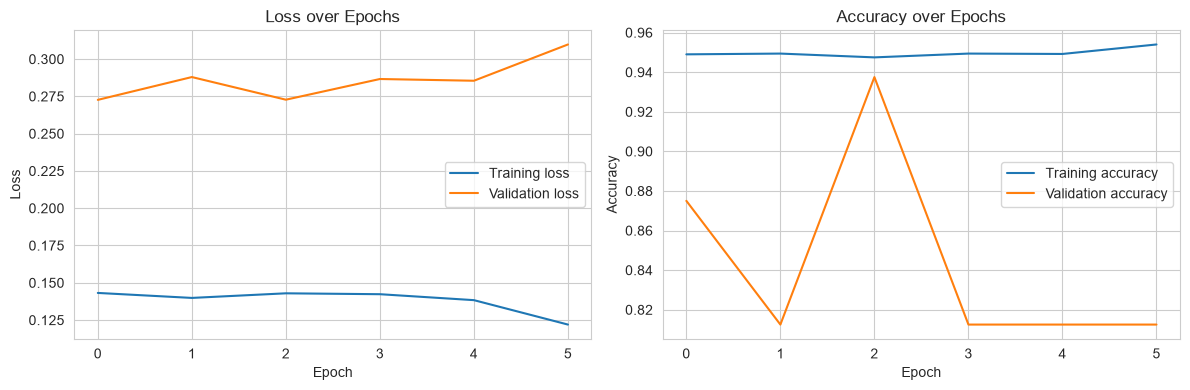

In [31]:
# Plot training and validation loss over epochs.
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
# Evaluate the trained model on the held-out test set.
# This gives an unbiased estimate of model performance on unseen data.
test_loss, test_accuracy = model.evaluate(test_ds, verbose=2)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

20/20 - 1s - 66ms/step - accuracy: 0.9054 - loss: 0.2697
Test loss: 0.2697
Test accuracy: 0.9054


## 9. Detailed test-set evaluation

The test split is kept untouched during training and validation. This section uses the trained model to examine class-specific performance, error patterns, and ranking quality.

Classification report:
              precision    recall  f1-score   support

      NORMAL     0.9147    0.8248    0.8674       234
   PNEUMONIA     0.9007    0.9538    0.9265       390

    accuracy                         0.9054       624
   macro avg     0.9077    0.8893    0.8970       624
weighted avg     0.9060    0.9054    0.9044       624



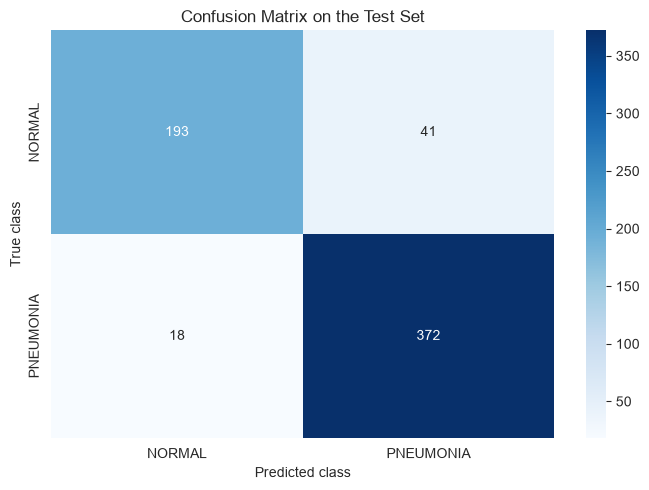

ROC-AUC: 0.9613


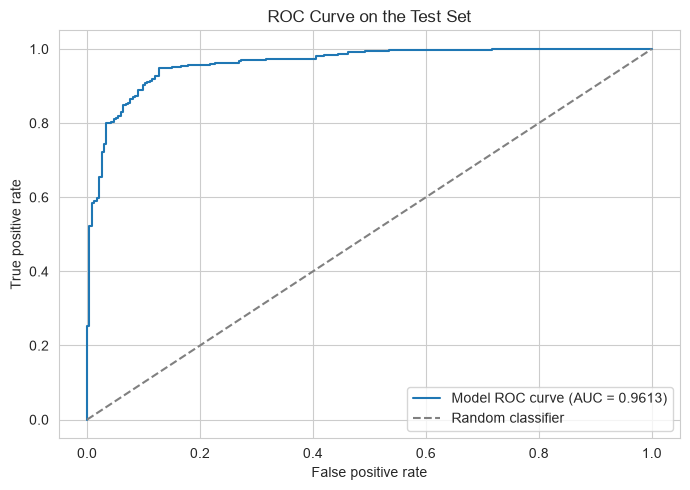

NORMAL recall: 0.8248
PNEUMONIA recall: 0.9538


In [33]:
# Generate predicted probabilities for every image in the untouched test split.
# The test set was not used during training or validation.
y_true = np.concatenate([labels.numpy().ravel() for _, labels in test_ds]).astype(int)
y_prob = model.predict(test_ds, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Print precision, recall, and F1 score for NORMAL and PNEUMONIA.
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print("Classification report:")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

# Plot the confusion matrix with class names on both axes.
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
)
plt.title("Confusion Matrix on the Test Set")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()

# Compute ROC-AUC from probabilities and plot the ROC curve.
roc_auc = roc_auc_score(y_true, y_prob)
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
print(f"ROC-AUC: {roc_auc:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Model ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
plt.title("ROC Curve on the Test Set")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Store the class-specific recall values for the interpretation section.
report = classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True)
normal_recall = report["NORMAL"]["recall"]
pneumonia_recall = report["PNEUMONIA"]["recall"]
print(f"NORMAL recall: {normal_recall:.4f}")
print(f"PNEUMONIA recall: {pneumonia_recall:.4f}")

## 10. Interpretation of test-set results

At the 0.5 probability threshold, the model achieved a PNEUMONIA recall of 0.9538 and a NORMAL recall of 0.8248. This means the model detected most of the real pneumonia cases, while it missed more cases from the NORMAL class. The test-set ROC-AUC was 0.9613, indicating strong overall ability to rank pneumonia cases above normal cases across possible thresholds.

PNEUMONIA recall is the most clinically important metric in this task because a false negative represents a patient with pneumonia who was classified as normal and could therefore miss timely clinical attention. A threshold of 0.5 is used here for the reported class labels, but other thresholds can produce similar overall accuracy while changing the balance between false positives and false negatives. In this medical screening context, reducing missed pneumonia cases should take priority over optimizing accuracy alone, so PNEUMONIA recall should be monitored carefully when selecting a decision threshold.

## 9. Notebook summary

This notebook covered the full workflow up to model evaluation: dataset inspection, preprocessing, architecture design, and CNN training with validation and test assessment. The model now uses the prepared chest X-ray data and has been trained and evaluated on the project splits without changing the original image files.